# **Importing Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette('Set2')

import warnings
warnings.filterwarnings("ignore")

!pip install category_encoders


# **Loading Data**

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/Dataset/Raw_Data/fraudTrain.csv')
test = pd.read_csv("/content/drive/MyDrive/Dataset/Raw_Data/fraudTest.csv")

In [ ]:
train.head(2)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0


In [ ]:
train.shape

(1296675, 23)

In [ ]:
train.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [ ]:
columns_drop = ["unix_time","merchant","first","street"]
train.drop(columns = columns_drop,inplace= True)
test.drop(columns = columns_drop,inplace= True)

**Droping Certain unuseful columns**


# **EDA**

In [ ]:
train.isna().sum().sum(),train.duplicated().sum()

(0, 0)

**No null or duplicate values**

In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1296675.0,6.483370e+05,3.743180e+05,0.000000e+00,3.241685e+05,6.483370e+05,9.725055e+05,1.296674e+06
cc_num,1296675.0,4.171920e+17,1.308806e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,1296675.0,7.035104e+01,1.603160e+02,1.000000e+00,9.650000e+00,4.752000e+01,8.314000e+01,2.894890e+04
zip,1296675.0,4.880067e+04,2.689322e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.978300e+04
lat,1296675.0,3.853762e+01,5.075808e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1296675.0,-9.022634e+01,1.375908e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1296675.0,8.882444e+04,3.019564e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06
merch_lat,1296675.0,3.853734e+01,5.109788e+00,1.902779e+01,3.473357e+01,3.936568e+01,4.195716e+01,6.751027e+01
merch_long,1296675.0,-9.022646e+01,1.377109e+01,-1.666712e+02,-9.689728e+01,-8.743839e+01,-8.023680e+01,-6.695090e+01
is_fraud,1296675.0,5.788652e-03,7.586269e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   last                   1296675 non-null  object 
 6   gender                 1296675 non-null  object 
 7   city                   1296675 non-null  object 
 8   state                  1296675 non-null  object 
 9   zip                    1296675 non-null  int64  
 10  lat                    1296675 non-null  float64
 11  long                   1296675 non-null  float64
 12  city_pop               1296675 non-null  int64  
 13  job                    1296675 non-null  object 
 14  dob               

**There are a lot of categorical features! So we need to encode them**

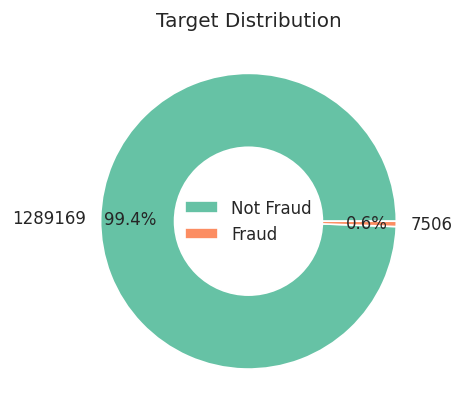

In [ ]:
#Target Distribution

donut = train["is_fraud"].value_counts().reset_index()

labels = ["Not Fraud", "Fraud"]
explode = (0, 0)

fig, ax = plt.subplots(dpi=120, figsize=(8, 4))
plt.pie(donut["count"],
        labels=donut["count"],
        autopct="%1.1f%%",
        pctdistance=0.8,
        explode=explode)

centre_circle = plt.Circle((0.0, 0.0), 0.5, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Target Distribution")
plt.legend(labels, loc="center", frameon=False)
plt.show();

**Highly imbalanced classes** Because of this, Oversampling/Undersampling can be used in the model.

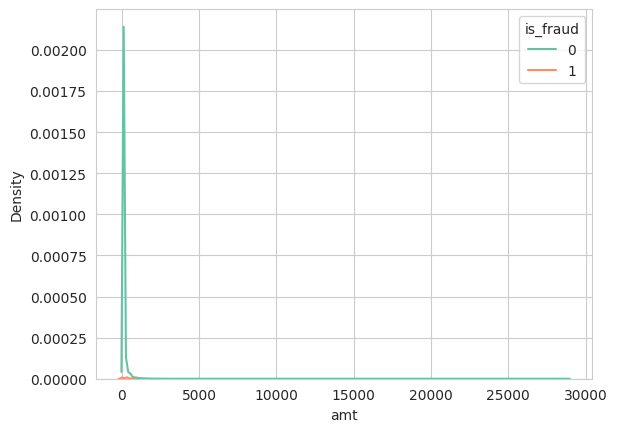

In [ ]:
sns.kdeplot(x="amt", hue="is_fraud",data=train);

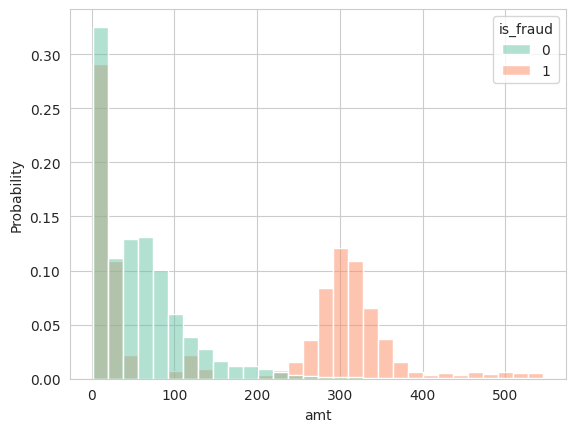

In [ ]:
pct99 = train["amt"].quantile(0.99)
sns.histplot(x="amt", hue="is_fraud", bins=30,
             stat="probability", data=train[train["amt"] <= pct99],
             common_norm=False);

**the probability distribution behaves differently for each value of "is_fraud".**

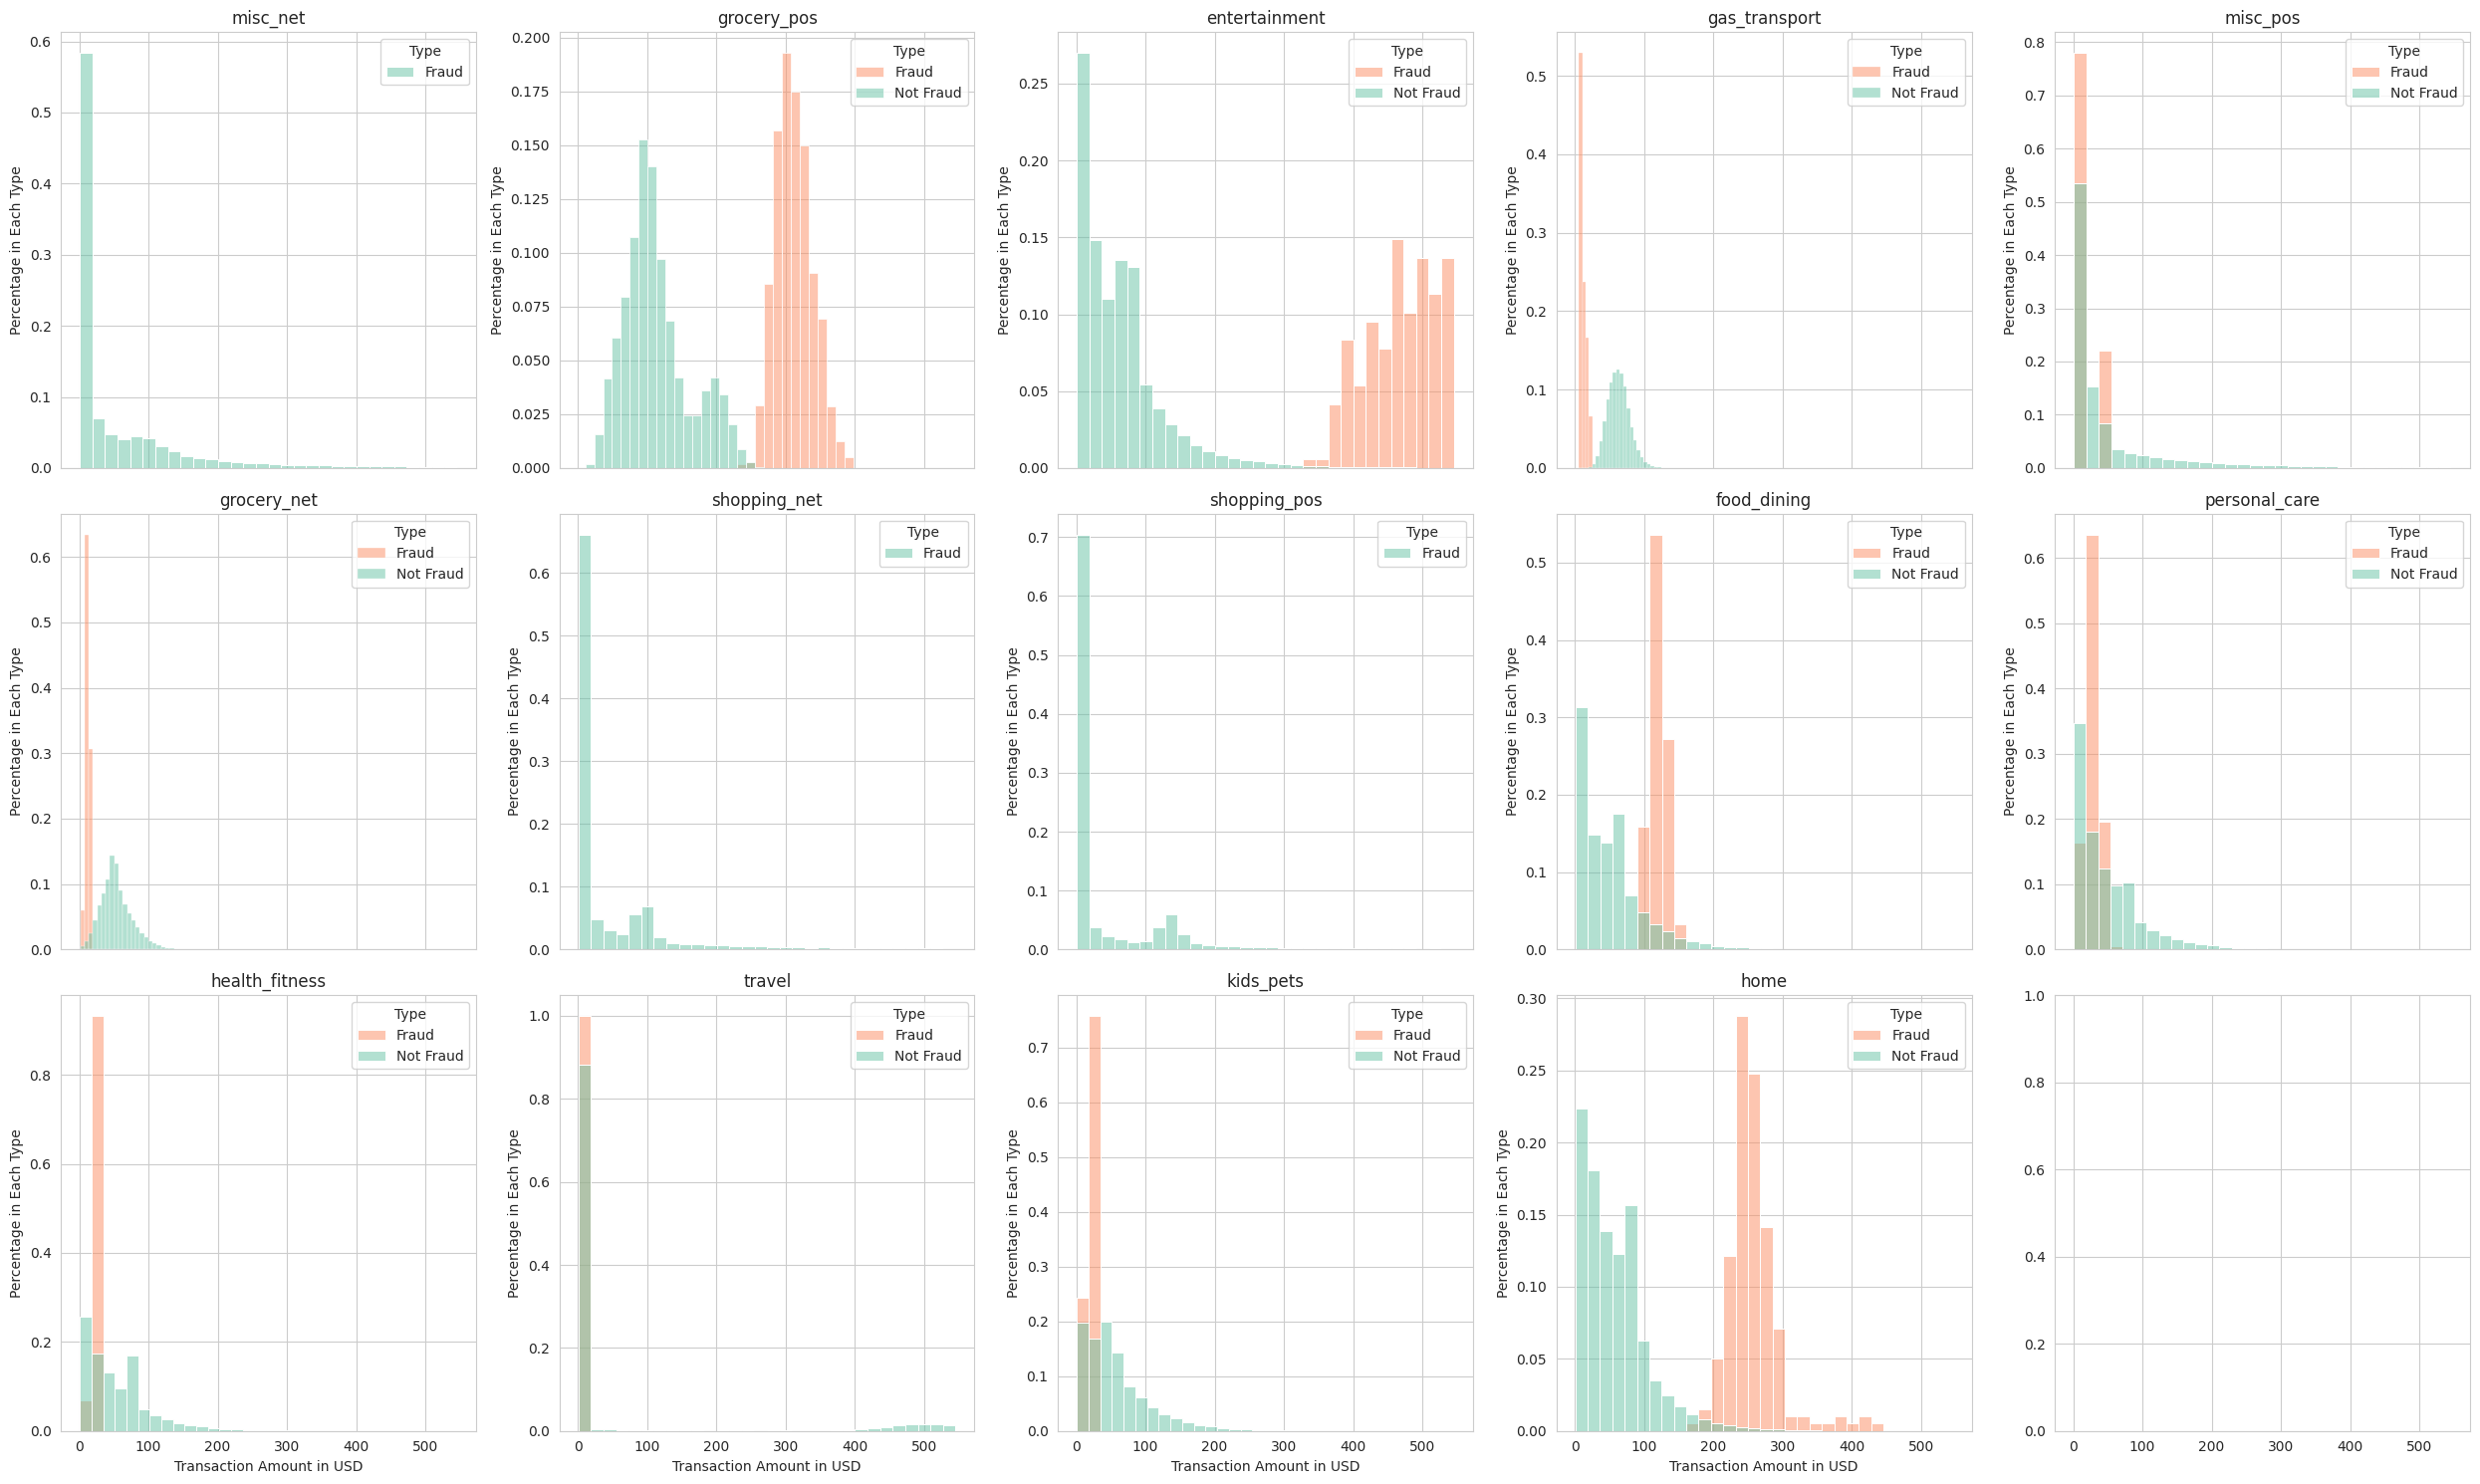

In [ ]:
import math
categories = train['category'].unique()

num_plots = len(categories)
num_rows = math.isqrt(num_plots)
num_cols = math.ceil(num_plots / num_rows)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(
    5*num_cols, 5*num_rows), sharex=True)

for ax, category in zip(axes.ravel(),categories):

    data_category = train[train['category'] == category]

    sns.histplot(x='amt', data=data_category[data_category['amt'] <= pct99],
                 hue='is_fraud', stat='probability',
                 common_norm=False, bins=30, ax=ax)

    ax.set_ylabel('Percentage in Each Type')
    ax.set_xlabel('Transaction Amount in USD')
    ax.set_title(f'{category}')
    ax.legend(title='Type', labels=['Fraud', 'Not Fraud'])

plt.tight_layout()
plt.show();

**There are patterns in categories hence we must consider categories for modelling**

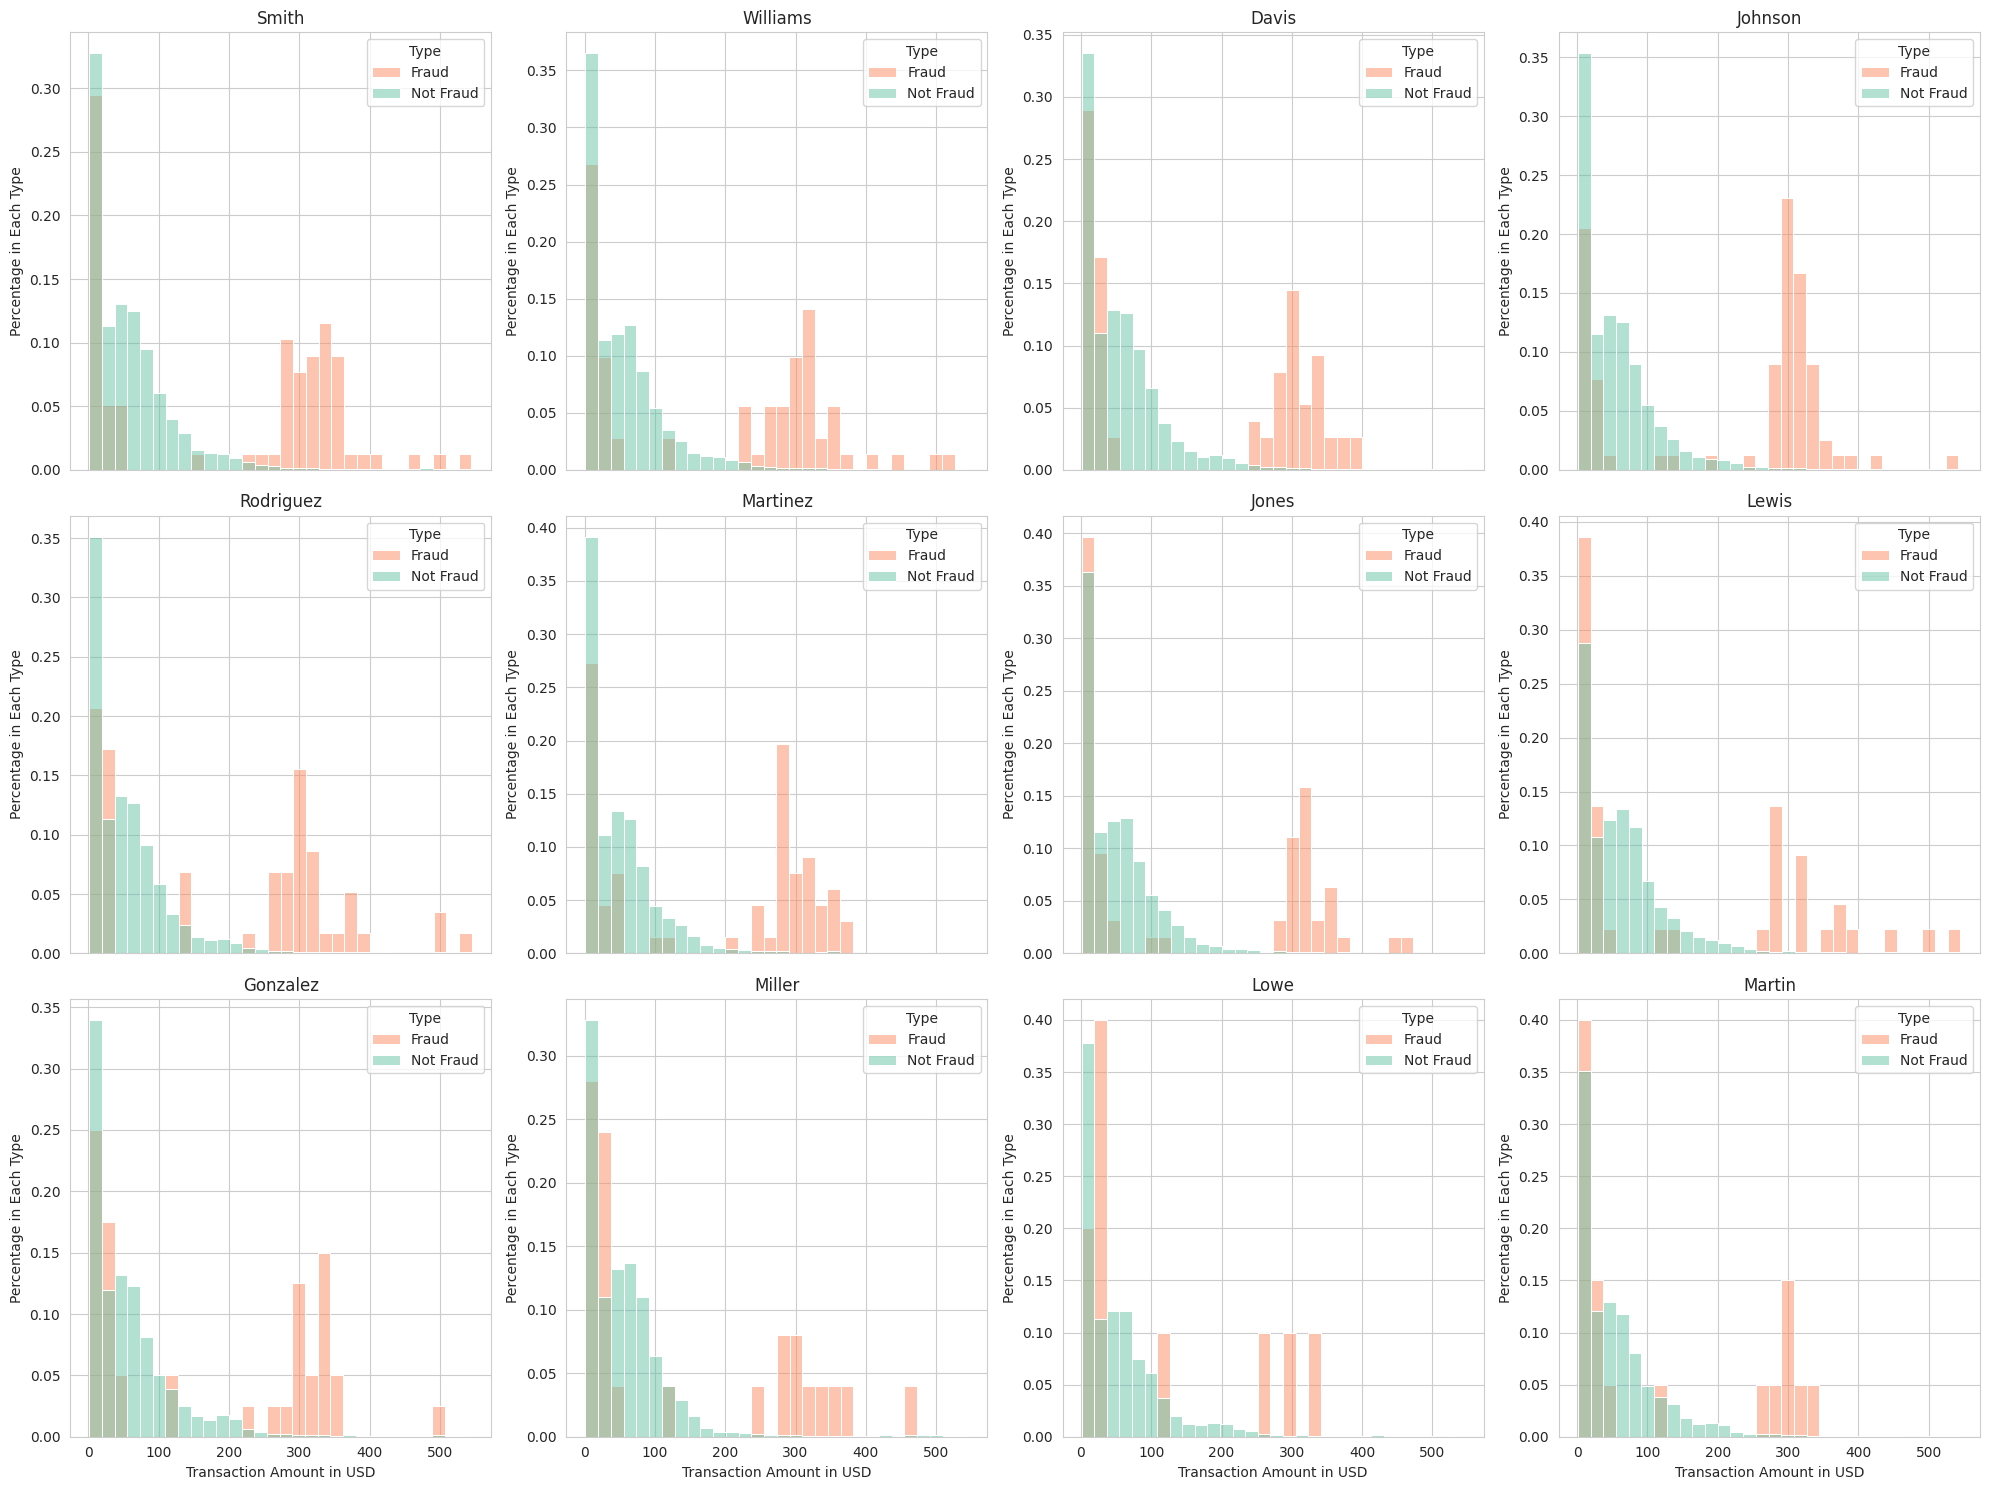

In [ ]:
import math
lastnames = train['last'].value_counts().index[:12]

num_plots = len(lastnames)
num_rows = math.isqrt(num_plots)
num_cols = math.ceil(num_plots / num_rows)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(
    5*num_cols, 5*num_rows), sharex=True)



for ax, lastname in zip(axes.ravel(),lastnames):

    data_lastname = train[train['last'] == lastname]

    sns.histplot(x='amt', data=data_lastname[data_lastname['amt'] <= pct99],
                 hue='is_fraud', stat='probability',
                 common_norm=False, bins=30, ax=ax)

    ax.set_ylabel('Percentage in Each Type')
    ax.set_xlabel('Transaction Amount in USD')
    ax.set_title(f'{lastname}')
    ax.legend(title='Type', labels=['Fraud', 'Not Fraud'])

plt.tight_layout()
plt.show();

**There are patterns in lastnames as well hence we must consider Lastnames for modelling**

In [ ]:
train["state"].value_counts().shape

(51,)

In [ ]:
train.groupby("state")["is_fraud"].value_counts()

state  is_fraud
AK     0            2084
       1              36
AL     0           40774
       1             215
AR     0           30966
                   ...  
WI     1             163
WV     0           25545
       1             146
WY     0           19212
       1             110
Name: count, Length: 101, dtype: int64

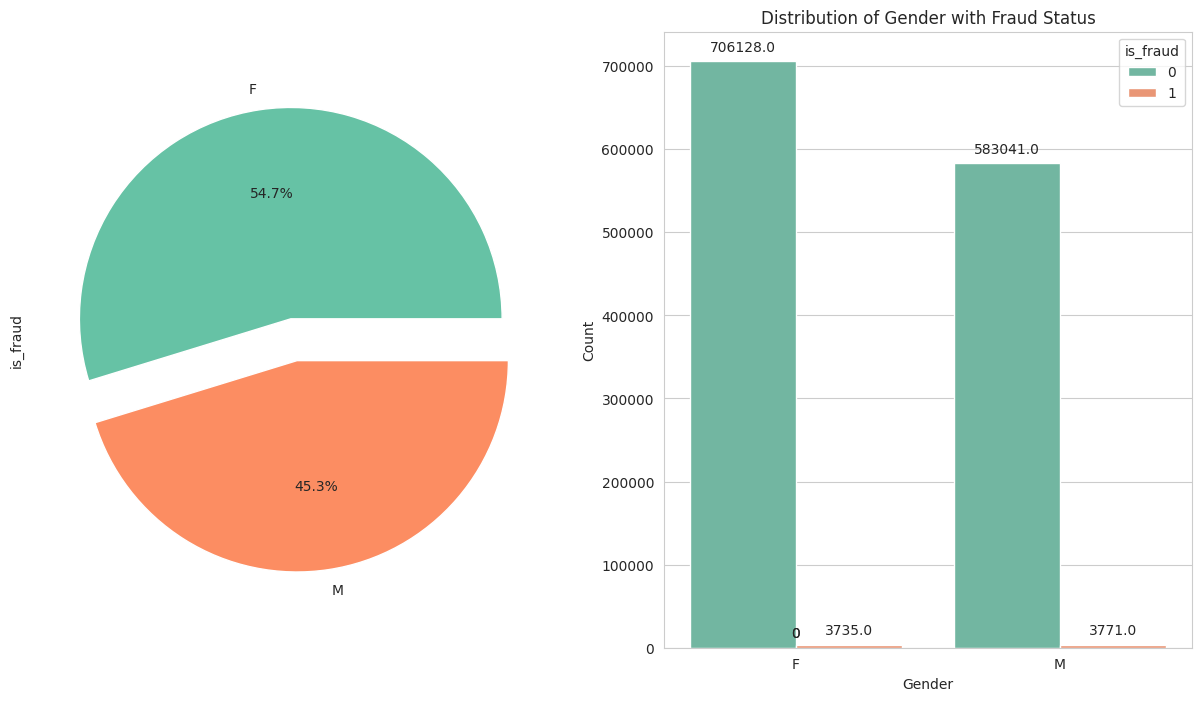

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig,axb = plt.subplots(ncols=2,nrows=1,figsize=(15, 8))

#Gender Distribution
explode = [0.1, 0.1]
train.groupby('gender')['is_fraud'].count().plot.pie(explode=explode, autopct="%1.1f%%",ax=axb[0]);

ax = sns.countplot(x="gender", hue="is_fraud", data=train,ax=axb[1])

# Add values on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Set labels and title
plt.title("Distribution of Gender with Fraud Status")
plt.xlabel("Gender")
plt.ylabel("Count")

# Show the plot
plt.show()

**Females are doing more transactions but males are more likely to make fraud transaction**

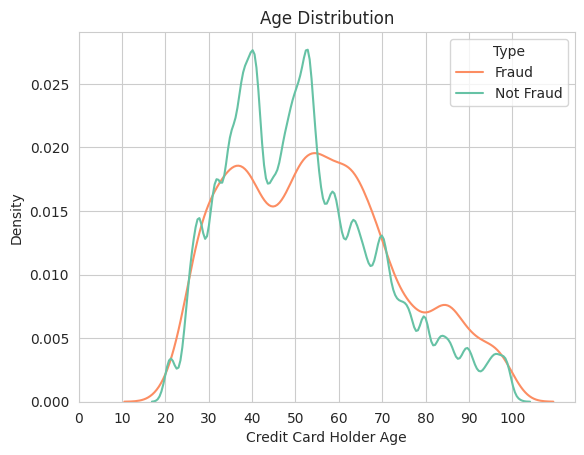

In [ ]:
import datetime as dt

train['age'] = dt.date.today().year-pd.to_datetime(train['dob']).dt.year
test['age'] = dt.date.today().year-pd.to_datetime(test['dob']).dt.year

ax = sns.kdeplot(x='age', data=train, hue='is_fraud', common_norm=False)
ax.set_xlabel('Credit Card Holder Age')
ax.set_ylabel('Density')
plt.xticks(np.arange(0, 110, 10))
plt.title('Age Distribution')
plt.legend(title='Type', labels=['Fraud', 'Not Fraud']);

**age has a less major impact on target**

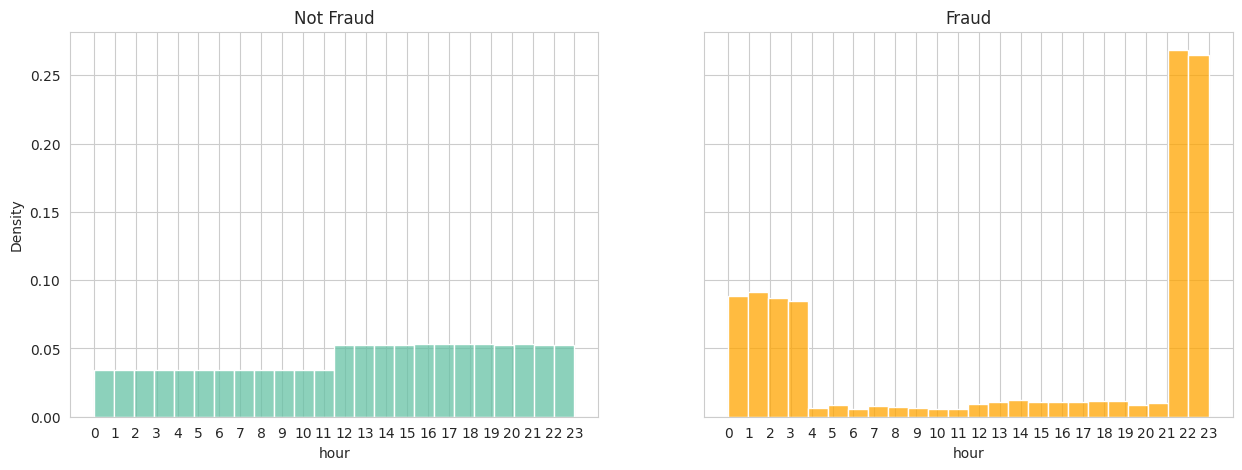

In [ ]:
train['hour'] = pd.to_datetime(train['trans_date_trans_time']).dt.hour
test['hour'] = pd.to_datetime(test['trans_date_trans_time']).dt.hour

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5), sharey=True)

ax1 = sns.histplot(x='hour', data=train[train["is_fraud"] == 0],
                   stat="density", bins=24, ax=ax1)

ax2 = sns.histplot(x='hour', data=train[train["is_fraud"] == 1],
                   stat="density", bins=24, ax=ax2, color="orange")

ax1.set_title("Not Fraud")
ax2.set_title("Fraud")

ax1.set_xticks(np.arange(24))
ax2.set_xticks(np.arange(24));

**It is clear that fraud transactions mainly occur at midnight.**

# **Preparing Data For Modelling**

In [ ]:
train.dtypes

,0
Unnamed: 0,int64
trans_date_trans_time,object
cc_num,int64
category,object
amt,float64
last,object
gender,object
city,object
state,object
zip,int64


In [ ]:
train["gender"]= train["gender"].apply(lambda x: 1 if x == "M" else 0)
test["gender"]= test["gender"].apply(lambda x: 1 if x == "M" else 0)

In [ ]:
import category_encoders as ce

def apply_woe(train, columns, target_col):
    woe = ce.WOEEncoder()

    for col in columns:
        X = train[col]
        y = train[target_col]

        new_col_name = f"{col}_WOE"
        train[new_col_name] = woe.fit_transform(X, y)

    return train


columns_to_encode = ["category", "state", "city", "job","last"]
target_column = "is_fraud"

train = apply_woe(train, columns_to_encode, target_column)
test = apply_woe(test, columns_to_encode, target_column)

In [ ]:
col_drop = ["is_fraud","trans_date_trans_time","trans_num","dob","category", "state", "city", "job","last"]
X_train,X_test,y_train,y_test = train.drop(columns=col_drop),test.drop(columns=col_drop),train["is_fraud"],test["is_fraud"]

In [ ]:
X_train.dtypes

,0
Unnamed: 0,int64
cc_num,int64
amt,float64
gender,int64
zip,int64
lat,float64
long,float64
city_pop,int64
merch_lat,float64
merch_long,float64


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=23)
# X_undersampled, y_undersampled = rus.fit_resample(X_train, y_train)
X_undersampled, y_undersampled = X_train, y_train

**Tried Undersampling but without Undersampling model has greater score so commented it**

In [ ]:
# y_train.value_counts(),y_undersampled.value_counts()

**undersampled normal transactions from 12L to 75k**

In [ ]:
X_undersampled.sample(2)

,Unnamed: 0,cc_num,amt,gender,zip,lat,long,city_pop,merch_lat,merch_long,age,hour,category_WOE,state_WOE,city_WOE,job_WOE,last_WOE
261964,261964,213156747557083,5.03,1,91206,34.1556,-118.2322,172817,33.189595,-117.944026,43,18,-0.847622,0.002014,-0.234112,-0.294947,-0.595614
445160,445160,3533742182628021,22.75,1,29455,32.8357,-79.8217,20478,32.628297,-79.236759,28,1,-0.670421,0.138662,-0.311088,0.275934,-0.311088


<Axes: >

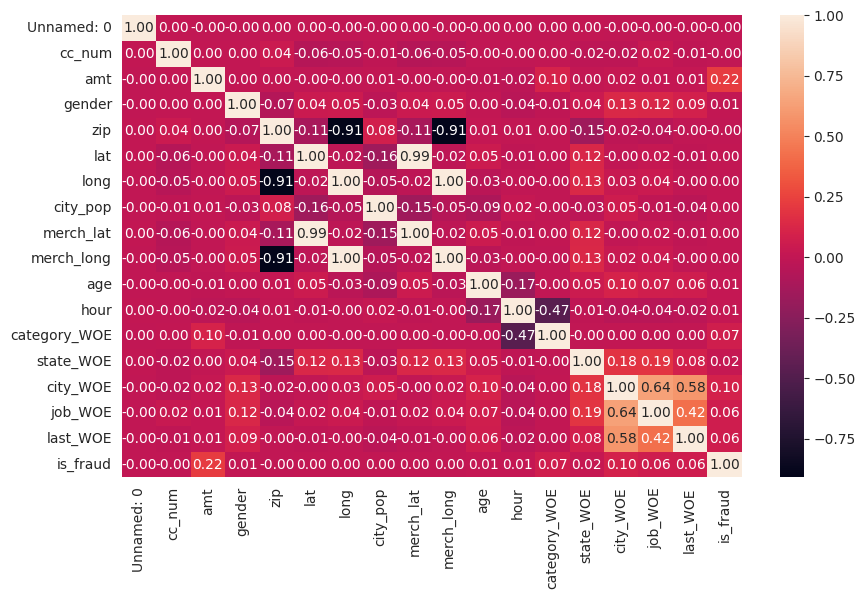

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(pd.concat([X_undersampled,y_undersampled],axis=1).corr(),annot=True,fmt='.2f')

**Amount has the highest corelation with fraud other columns have very negligible effect on fraud transaction**

In [ ]:
# col_d = ["zip","lat","long","city_pop","merch_lat", "merch_long", "cc_num"]
col_d = []

X_train = X_undersampled.drop(columns=col_d)
X_test =  X_test.drop(columns=col_d)
y_train = y_undersampled

**Tried Dropping these columns but score is greater keeping these columns**

In [ ]:
X_train.head(2)

,Unnamed: 0,cc_num,amt,gender,zip,lat,long,city_pop,merch_lat,merch_long,age,hour,category_WOE,state_WOE,city_WOE,job_WOE,last_WOE
0,0,2703186189652095,4.97,0,28654,36.0788,-81.1781,3495,36.011293,-82.048315,37,0,0.924914,-0.156457,-2.469513,-1.080186,-2.469513
1,1,630423337322,107.23,0,99160,48.8878,-118.2105,149,49.159047,-118.186462,47,0,0.898799,-0.122657,-3.027790,-0.904144,-0.673638


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((1296675, 17), (1296675,), (555719, 17), (555719,))

In [ ]:
#classification report
from sklearn.metrics import classification_report,confusion_matrix,precision_score,accuracy_score

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
rf.score(X_test,y_test)

0.9988951250542091

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.96      0.74      0.84      2145

    accuracy                           1.00    555719
   macro avg       0.98      0.87      0.92    555719
weighted avg       1.00      1.00      1.00    555719



<Axes: >

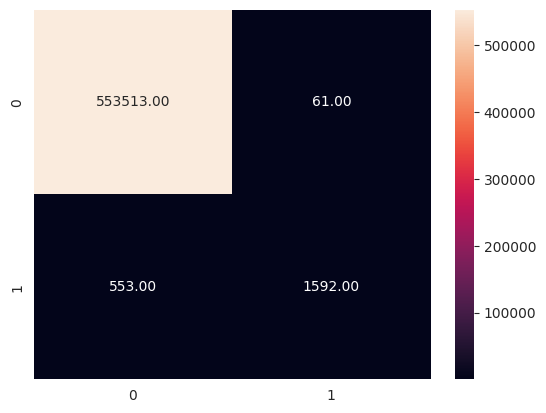

In [ ]:
y_pred = rf.predict(X_test)
print(classification_report(y_test,y_pred))
cnf = confusion_matrix(y_test,y_pred)
sns.heatmap(cnf,annot=True,fmt=".2f")

**Feature Importance**

In [ ]:
print("Accuracy: ", accuracy_score(y_test,y_pred))
print("Precision: ", precision_score(y_test,y_pred))

Accuracy:  0.9988951250542091
Precision:  0.9630973986690865


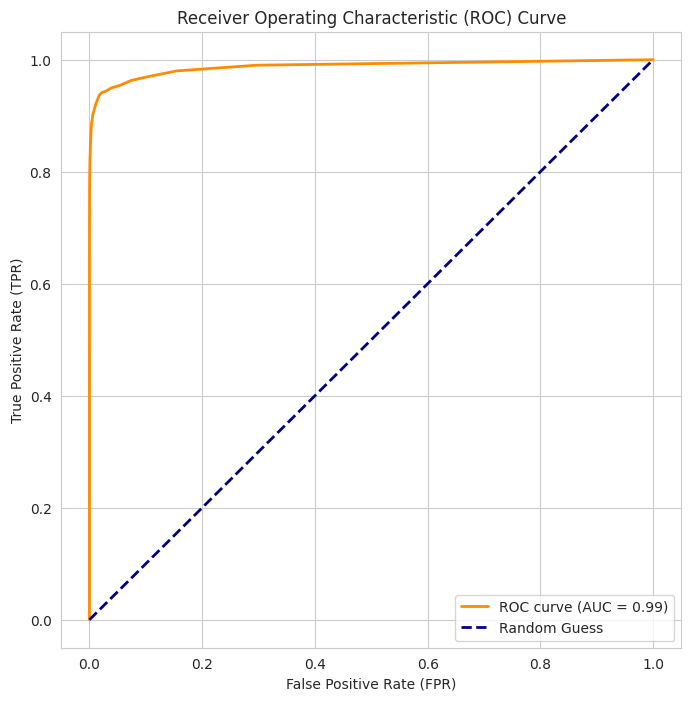

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, auc
y_prob = rf.predict_proba(X_test)[:, 1]

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate the AUC (Area Under the Curve) score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

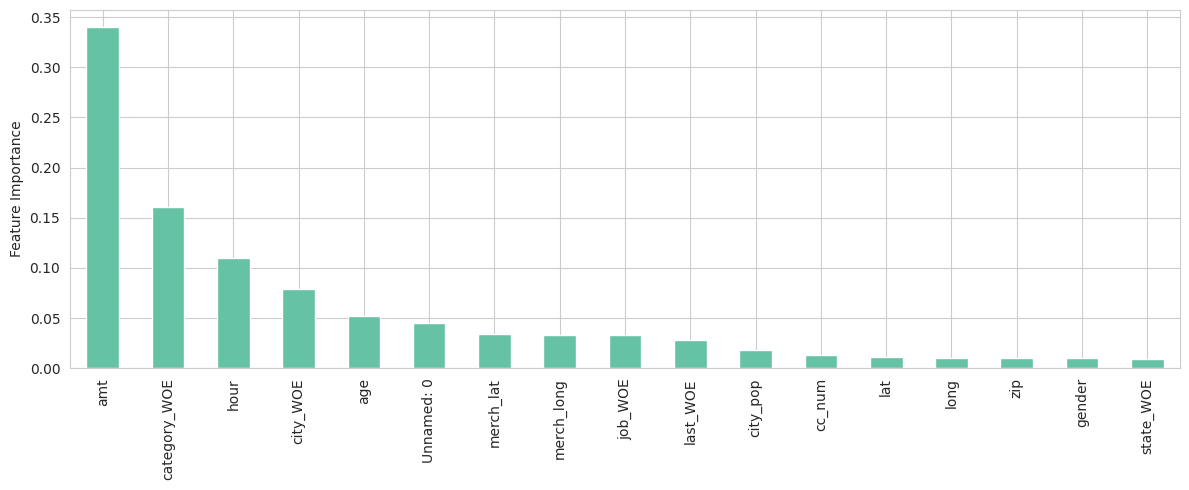

In [ ]:
importances = rf.feature_importances_
forest_importances = pd.Series(importances,index=X_undersampled.columns)
fig, ax = plt.subplots(figsize=(12, 5))
forest_importances.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_ylabel("Feature Importance")
fig.tight_layout();

# Conclusion

In this problem, it is crucial to look at precision score besides the accuracy score because of highly imbalanced dataset

Since our problem is related to fraud transactions, the model with low false negatives (transactions that are predicted as non-frauds and but actually are fraudulents) is better.

in this problem the precision and recall metric are the most important for the model.